<a href="https://colab.research.google.com/github/sayali-jatrate/project1/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
from google.colab import files # Added for file upload

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score


from google.colab import files
uploaded = files.upload()



Saving ai_impact_student_performance_dataset.csv to ai_impact_student_performance_dataset (1).csv


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [ ]:

import pandas as pd
df=pd.read_csv('ai_impact_student_performance_dataset.csv')
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [ ]:
# =========================================
# 3. ANALYSE DATA
# =========================================
print("First 5 rows:\n", df.head())
print("\nInfo:\n")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())


First 5 rows:
    student_id  age  gender grade_level  study_hours_per_day  uses_ai  \
0           1   20  Female    1st Year                  2.5        1   
1           2   17    Male        12th                  3.4        1   
2           3   24    Male    3rd Year                  0.8        0   
3           4   21  Female        12th                  4.4        0   
4           5   18   Other    3rd Year                  3.5        1   

   ai_usage_time_minutes   ai_tools_used ai_usage_purpose  \
0                    170             NaN        Exam Prep   
1                    123             NaN            Notes   
2                     35         Copilot    Doubt Solving   
3                     45  ChatGPT+Gemini            Notes   
4                     21  ChatGPT+Gemini           Coding   

   ai_dependency_score  ...  concept_understanding_score  \
0                   10  ...                            4   
1                    4  ...                            8   
2    

In [ ]:
# =========================================
# 4. HANDLE NULL VALUES (REPLACE WITH MEAN)
import pandas as pd
import numpy as np

# Load dataset (if not already loaded)
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# Check missing values before
print("Missing values BEFORE:\n", df.isnull().sum())

# Fill numeric columns with mean
for col in df.select_dtypes(include=np.number):
    mean_value = df[col].mean()
    df[col].fillna(mean_value, inplace=True)

# Fill categorical columns with mode (recommended)
for col in df.select_dtypes(include='object'):
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

# Check missing values after
print("\nMissing values AFTER:\n", df.isnull().sum())

# Preview dataset
print("\nFirst 5 rows:\n", df.head())


Missing values BEFORE:
 student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               0
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed          

/tmp/ipykernel_6653/20798318.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_value, inplace=True)
/tmp/ipykernel_6653/20798318.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
# =========================================
# DATASET CLEANING (COMPLETE PIPELINE)
# =========================================

import pandas as pd
import numpy as np

# =========================================
# 1. LOAD DATA
# =========================================
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

print("Initial Shape:", df.shape)

# =========================================
# 2. BASIC INFO
# =========================================
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

# =========================================
# 3. REMOVE DUPLICATES
# =========================================
df.drop_duplicates(inplace=True)
print("\nAfter removing duplicates:", df.shape)

# =========================================
# 4. HANDLE MISSING VALUES
# =========================================

# Check missing values
print("\nMissing Values BEFORE:\n", df.isnull().sum())

# Fill numeric columns with mean
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values AFTER:\n", df.isnull().sum())

# =========================================
# 5. CLEAN TEXT DATA (REMOVE EXTRA SPACES)
# =========================================
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# =========================================
# 6. CONVERT DOLLAR ($) TO NUMERIC (OPTIONAL)
# =========================================
def clean_dollar(x):
    try:
        if isinstance(x, str):
            return float(x.replace('$', '').replace(',', ''))
        return x
    except:
        return np.nan

# Example column (change if needed)
if 'salary' in df.columns:
    df['salary'] = df['salary'].apply(clean_dollar)

# =========================================
# 7. DATA TYPE CONVERSION
# =========================================
# Convert numeric columns stored as object
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

# =========================================
# 8. OUTLIER HANDLING (OPTIONAL)
# =========================================
# Remove extreme values using IQR method
for col in df.select_dtypes(include=np.number):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

# =========================================
# 9. FINAL CHECK
# =========================================
print("\nFinal Shape:", df.shape)
print("\nFinal Missing Values:\n", df.isnull().sum())

# Preview cleaned dataset
print("\nCleaned Data:\n", df.head())

# =========================================
# SAVE CLEAN DATA (OPTIONAL)
# =========================================
df.to_csv("cleaned_dataset.csv", index=False)

Initial Shape: (8000, 26)

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category'],
      dtype='object')

Data Types:
 student_id                           int64
age                                  int64
gender                              object
grade_level                         object
study_hours_per_day                float64
uses_ai                              int64
ai_usage_time_minutes                int64
ai_tools_used                       obje

/tmp/ipykernel_6653/622675295.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_6653/622675295.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin


Final Shape: (7112, 26)

Final Missing Values:
 student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category      

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import numpy as np

# Load dataset
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# --- Preprocessing Steps to handle categorical data (added to address ValueError) ---
# Handle null values for both numeric and categorical columns
# Fill numeric columns with mean
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in df.select_dtypes(include='object'):
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

# Apply Label Encoding to categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    # Convert to string first to handle potential mixed types or non-string objects gracefully
    df[col] = le.fit_transform(df[col].astype(str))
# --- End Preprocessing Steps ---

# -----------------------------
# Separate Features & Target
# -----------------------------
X = df.drop(['final_score'], axis=1)
y = df['final_score']

# -----------------------------
# Train-Test Split (BEST PRACTICE)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 1. STANDARD SCALER
# =========================================
sc = StandardScaler()

X_train_std = sc.fit_transform(X_train)   # fit only on training data
X_test_std = sc.transform(X_test)         # transform test data

print("Standard Scaled Data (first 5 rows):\n", X_train_std[:5])

# =========================================
# 2. MIN-MAX SCALER
# =========================================
mm = MinMaxScaler()

X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

print("\nMinMax Scaled Data (first 5 rows):\n", X_train_mm[:5])

Standard Scaled Data (first 5 rows):
 [[-1.10425781  1.28060809 -0.99464931  1.47797979 -1.56046444  0.7479667
   1.64031006 -0.60324081 -1.54770993 -0.18091499 -0.00858871 -1.41097972
  -0.85921997 -0.15724376  1.29114235  0.3852507  -0.51416446 -1.02938241
   1.19131587 -0.25761846  0.32936165  0.05504251 -0.16458114  0.35380193
   0.75400774]
 [ 0.76439875 -0.6237156  -0.99464931 -0.8706411   1.59376124  0.7479667
   1.01043787  0.89114323  1.569874    1.5586522   0.29641119  1.33905102
   0.87987168  0.49297166  0.36274381  0.59984526 -1.55069927  0.09651408
   0.43663549  0.02055906 -0.30029375 -0.7104637  -1.20678363  0.35380193
  -0.76110985]
 [ 0.74093736 -1.25849016 -0.99464931 -0.28348588  0.33207096  0.7479667
   1.31583044 -0.60324081 -1.54770993  0.51491189  0.19474456 -0.78076434
   1.57550834 -0.28728685  0.88184837  1.13923159 -0.51416446 -0.13643002
  -1.35858906  0.57691409  1.64591385  1.02932313  0.87762135  0.35380193
   0.75400774]
 [-1.05603161 -0.94110288  0.779

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset (if not already loaded)
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# Check categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:\n", cat_cols)

# Apply Label Encoding
le_dict = {}  # to store encoders for each column

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # ensure all values are string
    le_dict[col] = le  # store encoder (useful later)

# Show result
print("\nFirst 5 rows after label encoding:\n", df.head())

# Optional: Check transformed data types
print("\nUpdated Data Types:\n", df.dtypes)

Categorical Columns:
 Index(['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose',
       'performance_category'],
      dtype='object')

First 5 rows after label encoding:
    student_id  age  gender  grade_level  study_hours_per_day  uses_ai  \
0           1   20       0            3                  2.5        1   
1           2   17       1            2                  3.4        1   
2           3   24       1            5                  0.8        0   
3           4   21       0            2                  4.4        0   
4           5   18       2            5                  3.5        1   

   ai_usage_time_minutes  ai_tools_used  ai_usage_purpose  \
0                    170              5                 2   
1                    123              5                 4   
2                     35              3                 1   
3                     45              1                 4   
4                     21              1                 0   

   ai_depend

In [ ]:
# =========================================
# 7. FEATURE & TARGET
print("Columns in dataset:\n", df.columns)

# Ensure target column exists
if 'final_score' not in df.columns:
    raise ValueError("Column 'final_score' not found in dataset")

# Optional: drop unnecessary columns (like ID)
cols_to_drop = ['student_id'] if 'student_id' in df.columns else []

# Define features (X) and target (y)
X = df.drop(cols_to_drop + ['final_score'], axis=1)
y = df['final_score']

# Display shapes
print("\nShape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# Preview data
print("\nX sample:\n", X.head())
print("\ny sample:\n", y.head())

Columns in dataset:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category'],
      dtype='object')

Shape of X (features): (8000, 24)
Shape of y (target): (8000,)

X sample:
    age  gender  grade_level  study_hours_per_day  uses_ai  \
0   20       0            3                  2.5        1   
1   17       1            2                  3.4        1   
2   24       1            5                  0.8        0   
3   21       0            2                  4.4   

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# =========================================
# 9. TRAIN TEST SPLIT
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6400, 25)
X_test: (1600, 25)
y_train: (6400,)
y_test: (1600,)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# =========================================
# 11. SVR (SUPPORT VECTOR REGRESSION)
# =========================================
svr = SVR(kernel='rbf')   # try 'linear', 'poly'
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

# =========================================
# EVALUATION
# =========================================
print("----- Linear Regression -----")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\n----- SVR -----")
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("R2 Score:", r2_score(y_test, y_pred_svr))


----- Linear Regression -----
MSE: 22.053950118389192
R2 Score: 0.8814143229585404

----- SVR -----
MSE: 182.90977081399774
R2 Score: 0.016480998050775186


In [ ]:
# =========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# =========================================
# 1. BASIC OVERVIEW
# =========================================
print("First 5 Rows:\n", df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:\n", df.columns)

First 5 Rows:
    student_id  age  gender grade_level  study_hours_per_day  uses_ai  \
0           1   20  Female    1st Year                  2.5        1   
1           2   17    Male        12th                  3.4        1   
2           3   24    Male    3rd Year                  0.8        0   
3           4   21  Female        12th                  4.4        0   
4           5   18   Other    3rd Year                  3.5        1   

   ai_usage_time_minutes   ai_tools_used ai_usage_purpose  \
0                    170             NaN        Exam Prep   
1                    123             NaN            Notes   
2                     35         Copilot    Doubt Solving   
3                     45  ChatGPT+Gemini            Notes   
4                     21  ChatGPT+Gemini           Coding   

   ai_dependency_score  ...  concept_understanding_score  \
0                   10  ...                            4   
1                    4  ...                            8   
2    

In [ ]:
# 2. DATA TYPES & INFO
# =========================================
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_e

In [ ]:
# 3. STATISTICAL SUMMARY
# =========================================
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
        student_id         age  study_hours_per_day      uses_ai  \
count  8000.00000  8000.00000          8000.000000  8000.000000   
mean   4000.50000    18.96725             3.286938     0.641000   
std    2309.54541     3.15316             1.582171     0.479737   
min       1.00000    14.00000             0.500000     0.000000   
25%    2000.75000    16.00000             1.900000     0.000000   
50%    4000.50000    19.00000             3.300000     1.000000   
75%    6000.25000    22.00000             4.600000     1.000000   
max    8000.00000    24.00000             6.000000     1.000000   

       ai_usage_time_minutes  ai_dependency_score  \
count            8000.000000          8000.000000   
mean               88.989875             5.515125   
std                52.184077             2.883064   
min                 0.000000             1.000000   
25%                43.000000             3.000000   
50%                89.000000             6.000000   
75

In [ ]:
# 4. MISSING VALUES
# =========================================
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               0
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed                

In [ ]:
# 5. VALUE COUNTS (Categorical)
# =========================================
for col in df.select_dtypes(include='object'):
    print(f"\nValue counts for {col}:\n", df[col].value_counts())



Value counts for gender:
 gender
Male      3908
Female    3811
Other      281
Name: count, dtype: int64

Value counts for grade_level:
 grade_level
1st Year    1356
10th        1344
11th        1336
3rd Year    1334
12th        1321
2nd Year    1309
Name: count, dtype: int64

Value counts for ai_tools_used:
 ai_tools_used
ChatGPT+Gemini    1399
ChatGPT           1332
Gemini            1311
Claude            1310
Copilot           1286
Name: count, dtype: int64

Value counts for ai_usage_purpose:
 ai_usage_purpose
Exam Prep        1368
Doubt Solving    1342
Homework         1332
Coding           1315
Notes            1297
Name: count, dtype: int64

Value counts for performance_category:
 performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# =========================================
# LOAD YOUR DATASET
# =========================================
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# Set seed for reproducibility
np.random.seed(42)

# =========================================
# SELECT TARGET COLUMN FOR MISSING VALUES
# =========================================
col_name = 'final_score'   # 🔁 change if needed

if col_name in df.columns:

    # Select 10 random indices
    missing_index = np.random.choice(df.index, size=10, replace=False)

    # Insert NaN values
    df.loc[missing_index, col_name] = np.nan

    # Output
    print("Missing indices:\n", missing_index)
    print("\nRows with missing values:\n")
    print(df.loc[missing_index])

else:
    print(f"Column '{col_name}' not found in dataset.")

Missing indices:
 [2215 2582 1662 3027 4343 2680 1765 1123 4054 3761]

Rows with missing values:

      student_id  age  gender grade_level  study_hours_per_day  uses_ai  \
2215        2216   19    Male        10th                  4.6        0   
2582        2583   14  Female        11th                  4.8        0   
1662        1663   20  Female    1st Year                  2.4        1   
3027        3028   14  Female    1st Year                  1.2        1   
4343        4344   23    Male        11th                  3.7        1   
2680        2681   19    Male    2nd Year                  5.4        0   
1765        1766   17  Female    2nd Year                  5.0        0   
1123        1124   17    Male        10th                  5.2        0   
4054        4055   22    Male        10th                  0.9        1   
3761        3762   17    Male    3rd Year                  1.2        0   

      ai_usage_time_minutes   ai_tools_used ai_usage_purpose  \
2215        

In [ ]:
print("Columns:\n", df.columns)

# =========================================
# EXAMPLE FILTER (ADJUST BASED ON YOUR DATA)
# =========================================

# Calculate average of a numeric column
avg_score = df['final_score'].mean()

# Apply filtering
filtered_df = df[
    (df['study_hours_per_day'] > 3) &                 # example condition
    (df['final_score'] > avg_score)           # above average score
]

print("\nFiltered Data:\n", filtered_df)

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category'],
      dtype='object')

Filtered Data:
       student_id  age  gender grade_level  study_hours_per_day  uses_ai  \
1              2   17    Male        12th                  3.4        1   
3              4   21  Female        12th                  4.4        0   
5              6   20    Male    1st Year                  5.1        1   
8              9   20  Female        10th                  6.0   

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category'],
      dtype='object')


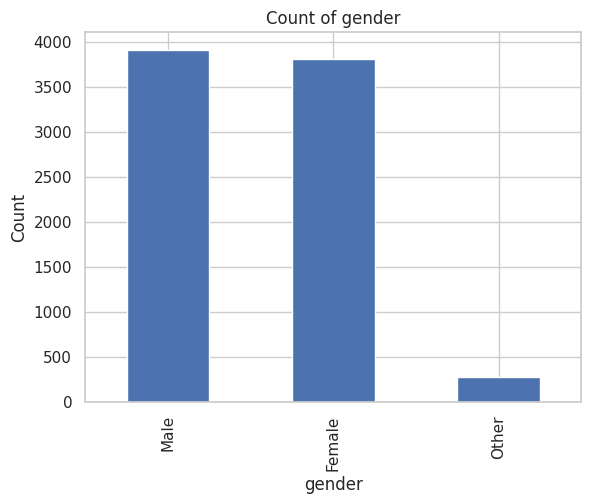

In [ ]:
print("Columns:\n", df.columns)

# =========================================
# SELECT A CATEGORICAL COLUMN
# =========================================
col = 'gender'   # 🔁 change if needed

if col in df.columns:
    df[col].value_counts().plot(kind='bar')

    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

else:
    print(f"Column '{col}' not found. Please choose a valid column.")

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category'],
      dtype='object')


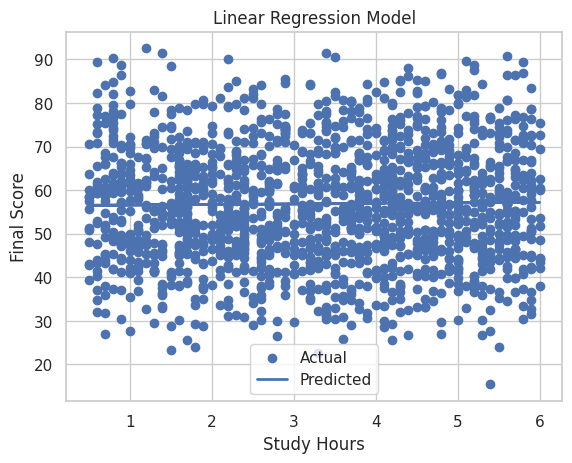

In [ ]:
print("Columns:\n", df.columns)

# =========================================
# SELECT FEATURE & TARGET
# =========================================
# Example: study_hours → final_score
X = df[['study_hours_per_day']]     # feature
y = df['final_score']       # target

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# MODEL TRAINING
# =========================================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================================
# PREDICTION
# =========================================
y_pred = model.predict(X_test)

# =========================================
# VISUALIZATION
# =========================================
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, linewidth=2, label='Predicted')

plt.xlabel('Study Hours')
plt.ylabel('Final Score')
plt.title('Linear Regression Model')
plt.legend()
plt.show()

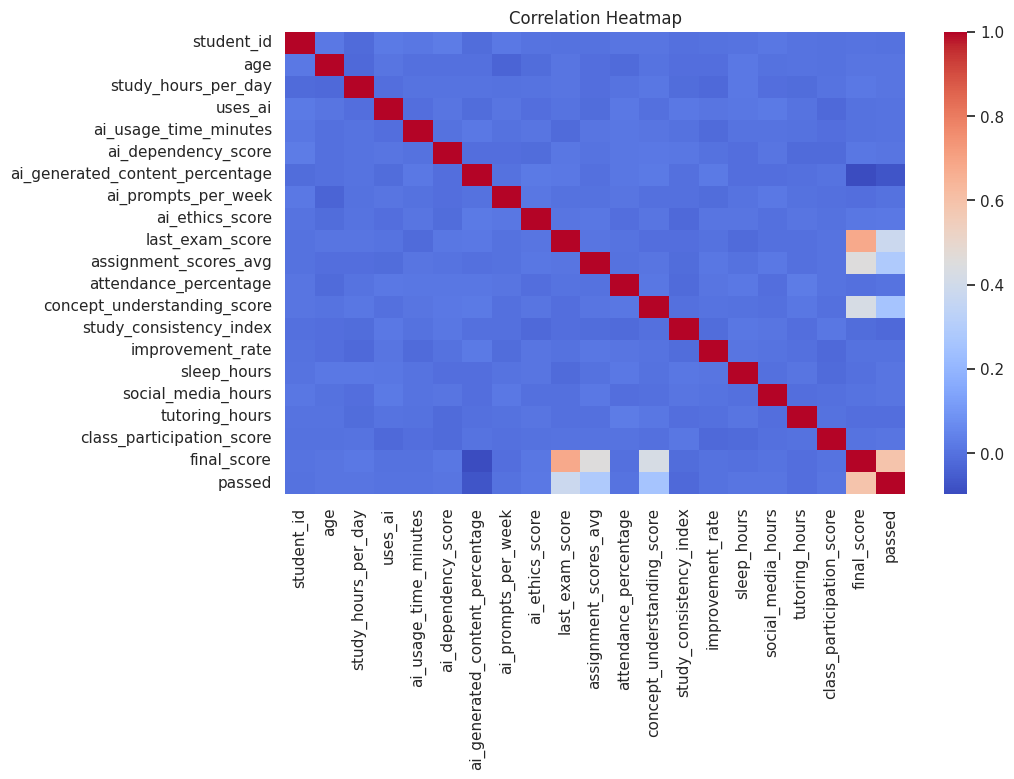

In [ ]:
# 7. CORRELATION MATRIX
# =========================================
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

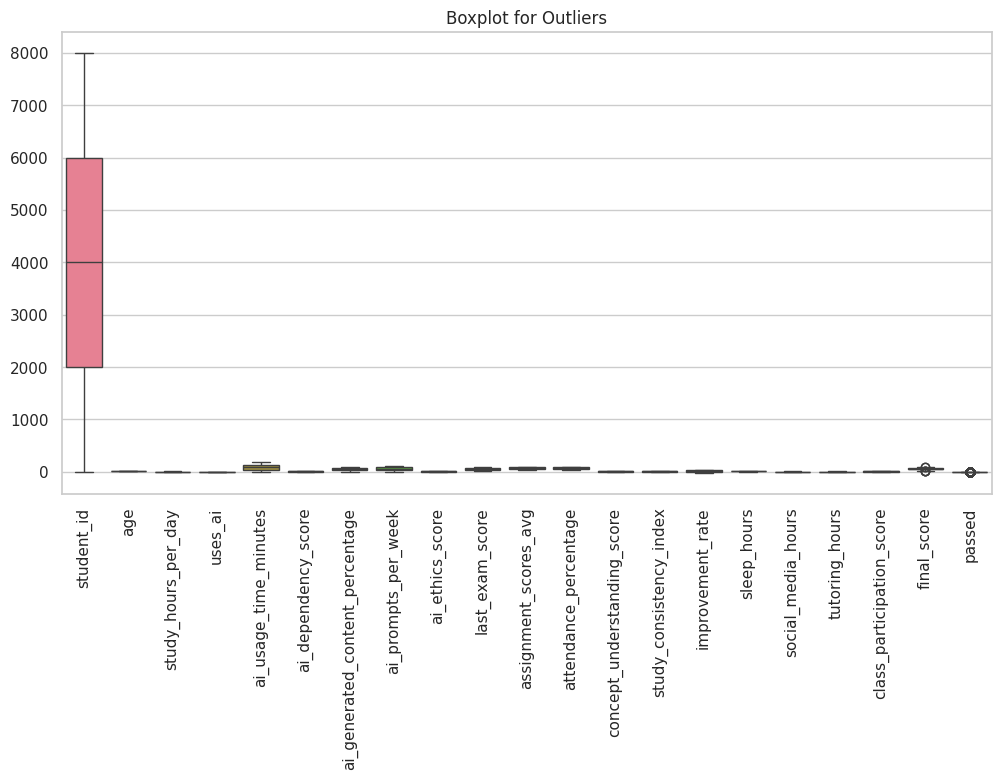

In [ ]:
# 8. BOXPLOT (Outliers detection)
# =========================================
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Boxplot for Outliers")
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

print("Columns:\n", df.columns)

# =========================================
# CREATE CLASSIFICATION TARGET
# =========================================
# Convert final_score into binary (High / Low)
threshold = df['final_score'].mean()

df['High_Performance'] = np.where(df['final_score'] > threshold, 1, 0)

# =========================================
# FEATURES & TARGET
# =========================================
X = df[['study_hours_per_day']]   # you can add more features
y = df['High_Performance']

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# MODEL TRAINING
# =========================================
model = LogisticRegression()
model.fit(X_train, y_train)

# =========================================
# PREDICTION
# =========================================
# Example: student with 5 study hours
prediction = model.predict([[5]])
probability = model.predict_proba([[5]])

print("Prediction (0 = Low, 1 = High):", prediction)
print("Probability:", probability)

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category', 'High_Performance'],
      dtype='object')
Prediction (0 = Low, 1 = High): [1]
Probability: [[0.48902033 0.51097967]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


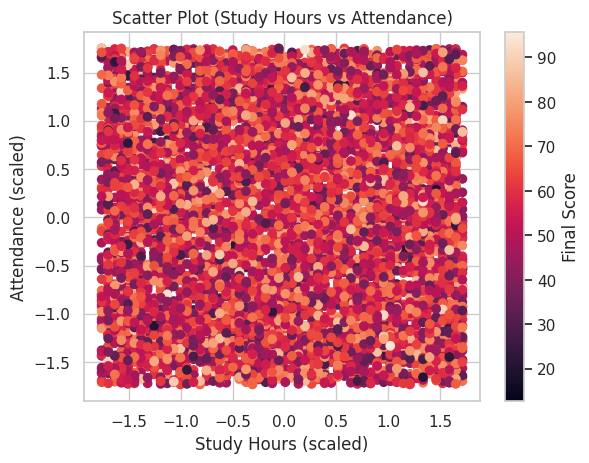

In [ ]:
X = df[['study_hours_per_day', 'attendance_percentage']]   # ❌ corrected

# Target (for coloring)
y = df['final_score']

# =========================================
# SCALING
# =========================================
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# =========================================
# SCATTER PLOT
# =========================================
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

plt.title("Scatter Plot (Study Hours vs Attendance)")
plt.xlabel("Study Hours (scaled)")
plt.ylabel("Attendance (scaled)")
plt.colorbar(label="Final Score")

plt.show()

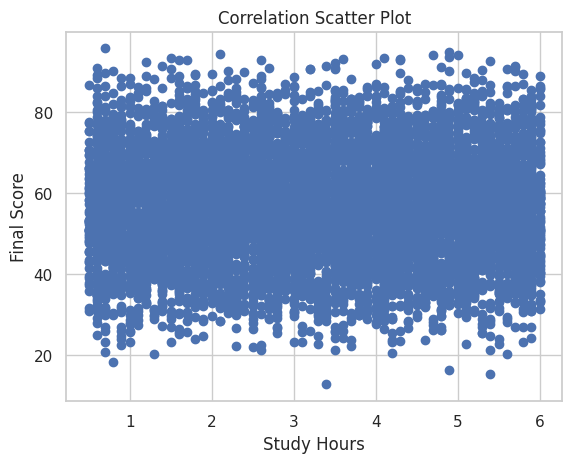

In [ ]:
X = df[['study_hours_per_day', 'final_score']].values

# =========================================
# SCATTER PLOT
# =========================================
plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Correlation Scatter Plot")

plt.show()

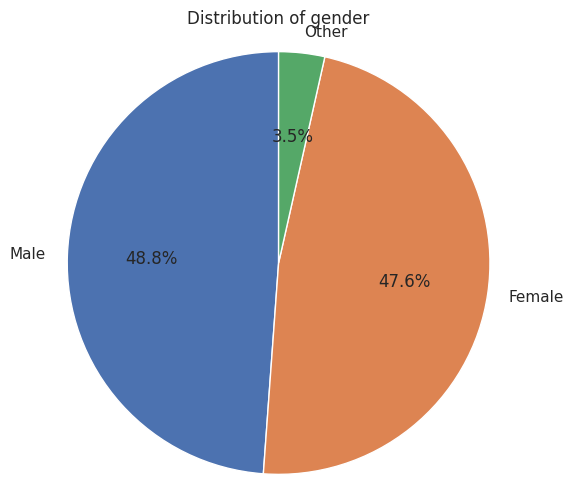

In [ ]:
col = 'gender'   # 🔁 change if needed

if col in df.columns:

    counts = df[col].value_counts()

    # =========================================
    # PIE CHART
    # =========================================
    plt.figure(figsize=(6, 6))

    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title(f"Distribution of {col}")
    plt.axis('equal')   # makes circle perfect

    plt.show()

else:
    print(f"Column '{col}' not found. Try another column.")

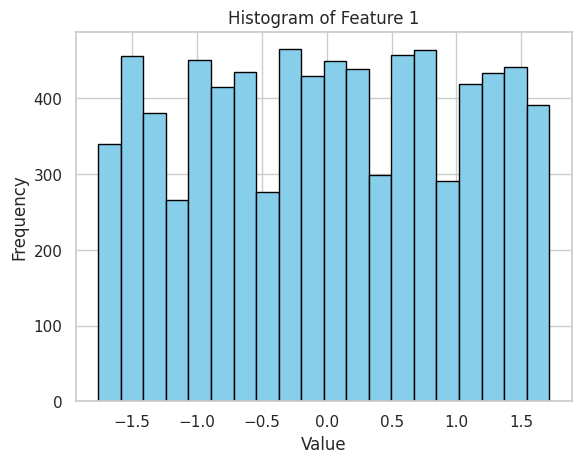

In [ ]:
plt.hist(X_scaled[:, 0], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Feature 1")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

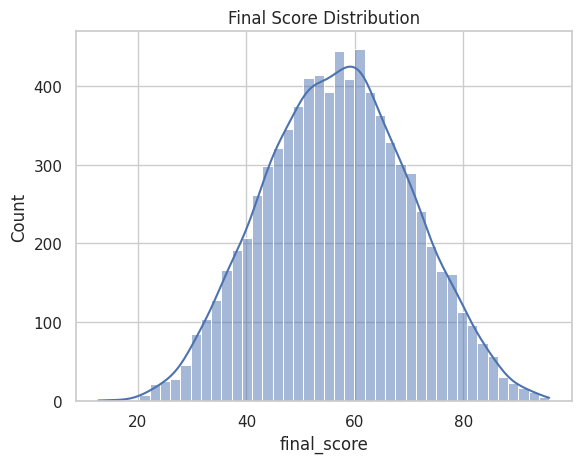

In [ ]:
# 9. RELATIONSHIP ANALYSIS
# =========================================
# Example: Study hours vs Final Score
if 'study_hours' in df.columns and 'final_score' in df.columns:
    sns.scatterplot(x=df['study_hours'], y=df['final_score'])
    plt.title("Study Hours vs Final Score")
    plt.show()
# 10. TARGET DISTRIBUTION
# =========================================
if 'final_score' in df.columns:
    sns.histplot(df['final_score'], kde=True)
    plt.title("Final Score Distribution")
    plt.show()

Correlation Matrix:
                                  student_id       age  study_hours_per_day  \
student_id                         1.000000  0.016347            -0.018194   
age                                0.016347  1.000000            -0.020504   
study_hours_per_day               -0.018194 -0.020504             1.000000   
uses_ai                            0.020702  0.006359            -0.009835   
ai_usage_time_minutes              0.013013 -0.004758             0.002130   
ai_dependency_score                0.025216 -0.002380             0.004208   
ai_generated_content_percentage   -0.014774 -0.003763             0.003263   
ai_prompts_per_week                0.018575 -0.034365             0.000951   
ai_ethics_score                    0.005220 -0.013394             0.002007   
last_exam_score                   -0.001756  0.010088             0.009136   
assignment_scores_avg              0.000307 -0.008140            -0.007500   
attendance_percentage              0.009116

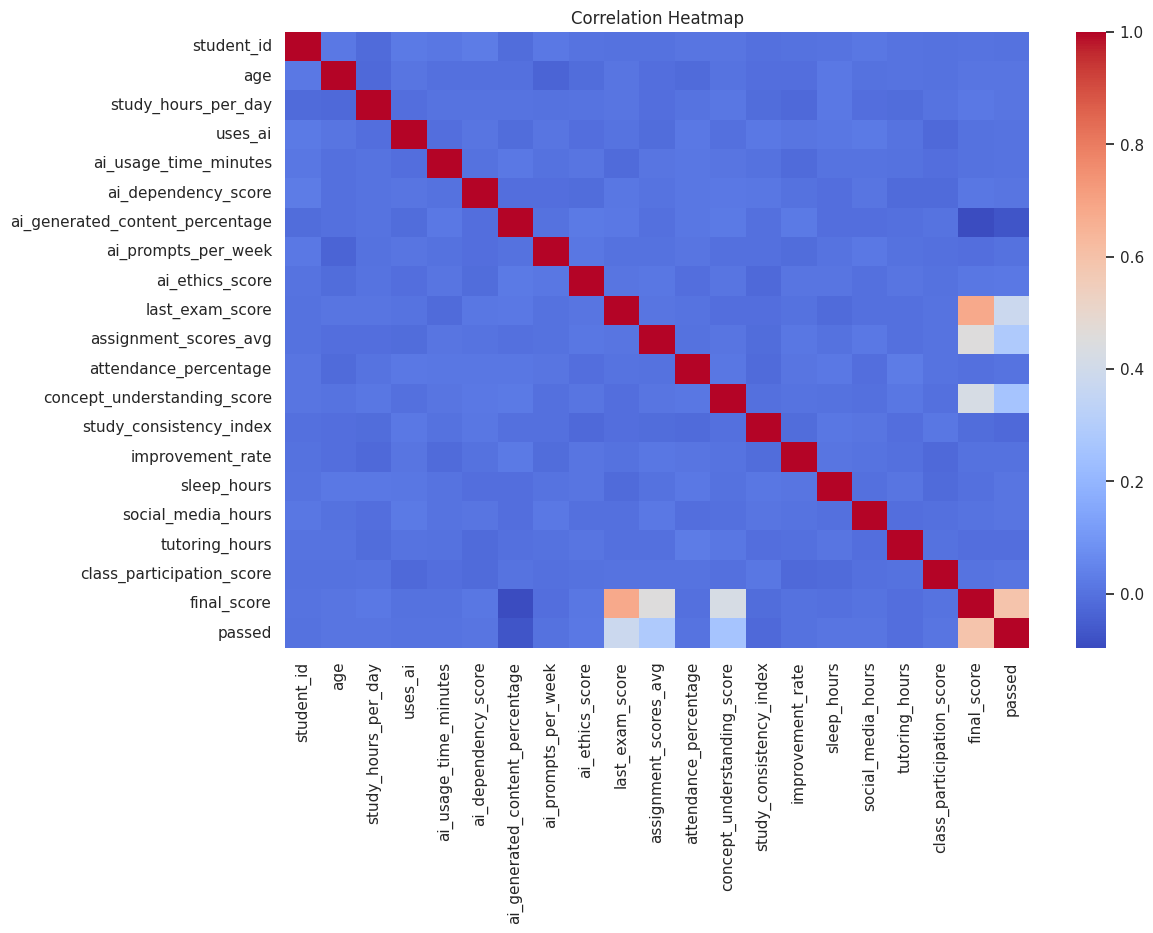


Highly Correlated Features (>|0.7|):

Correlation with Final Score:

final_score                        1.000000
last_exam_score                    0.681675
passed                             0.592637
assignment_scores_avg              0.454554
concept_understanding_score        0.423874
study_hours_per_day                0.015798
ai_dependency_score                0.014077
ai_ethics_score                    0.013269
age                                0.007615
social_media_hours                 0.004099
student_id                         0.003917
class_participation_score          0.003523
improvement_rate                  -0.001549
ai_usage_time_minutes             -0.001610
uses_ai                           -0.001628
attendance_percentage             -0.005182
sleep_hours                       -0.005785
tutoring_hours                    -0.008564
ai_prompts_per_week               -0.010148
study_consistency_index           -0.014126
ai_generated_content_percentage   -0.096552
Name: 

In [ ]:
# =========================================
# CORRELATION ANALYSIS (COMPLETE)
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# =========================================
# 1. SELECT NUMERICAL COLUMNS
# =========================================
num_df = df.select_dtypes(include='number')

# =========================================
# 2. CORRELATION MATRIX
# =========================================
corr_matrix = num_df.corr()

print("Correlation Matrix:\n", corr_matrix)

# =========================================
# 3. HEATMAP VISUALIZATION
# =========================================
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 4. HIGH CORRELATION PAIRS (IMPORTANT)
# =========================================
# Find features with high correlation (>0.7)
threshold = 0.7

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            value = corr_matrix.iloc[i, j]
            high_corr.append((col1, col2, value))

print("\nHighly Correlated Features (>|0.7|):")
for item in high_corr:
    print(item)

# =========================================
# 5. CORRELATION WITH TARGET
# =========================================
if 'final_score' in corr_matrix.columns:
    print("\nCorrelation with Final Score:\n")
    print(corr_matrix['final_score'].sort_values(ascending=False))

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category'],
      dtype='object')


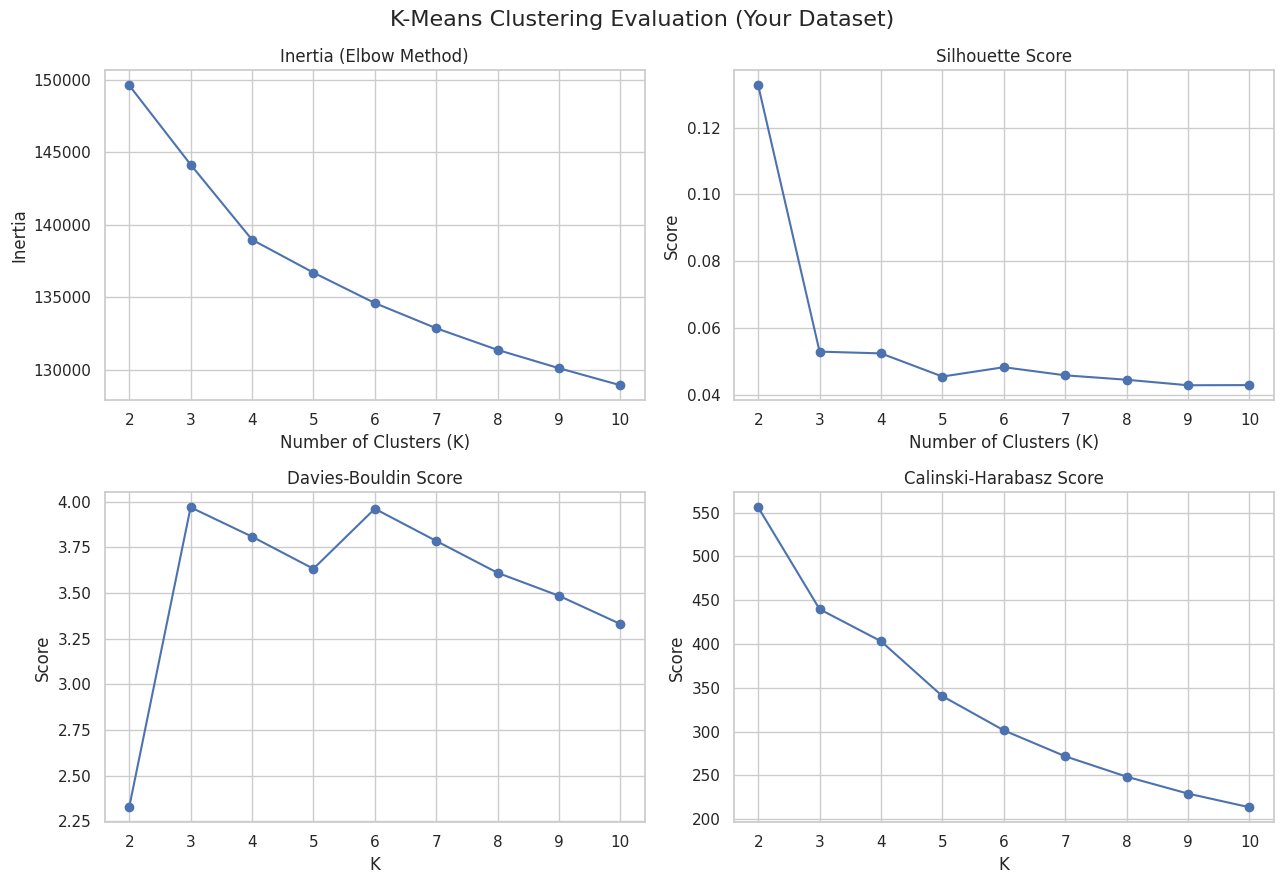

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# =========================================
# LOAD YOUR DATASET
# =========================================
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

print("Columns:\n", df.columns)

# =========================================
# SELECT NUMERICAL FEATURES ONLY
# =========================================
num_cols = df.select_dtypes(include=np.number).columns

# Drop target column if present
if 'final_score' in num_cols:
    num_cols = num_cols.drop('final_score')

X = df[num_cols].values

# =========================================
# FEATURE SCALING
# =========================================
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# =========================================
# K-MEANS EVALUATION
# =========================================
inertias = []
sil_scores = []
db_scores = []
ch_scores = []

K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# =========================================
# PLOTTING
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Elbow Method
axes[0,0].plot(K_range, inertias, 'o-')
axes[0,0].set_title('Inertia (Elbow Method)')
axes[0,0].set_xlabel('Number of Clusters (K)')
axes[0,0].set_ylabel('Inertia')

# Silhouette Score
axes[0,1].plot(K_range, sil_scores, 'o-')
axes[0,1].set_title('Silhouette Score')
axes[0,1].set_xlabel('Number of Clusters (K)')
axes[0,1].set_ylabel('Score')

# Davies-Bouldin
axes[1,0].plot(K_range, db_scores, 'o-')
axes[1,0].set_title('Davies-Bouldin Score')
axes[1,0].set_xlabel('K')
axes[1,0].set_ylabel('Score')

# Calinski-Harabasz
axes[1,1].plot(K_range, ch_scores, 'o-')
axes[1,1].set_title('Calinski-Harabasz Score')
axes[1,1].set_xlabel('K')
axes[1,1].set_ylabel('Score')

plt.suptitle('K-Means Clustering Evaluation (Your Dataset)', fontsize=16)
plt.tight_layout()
plt.show()

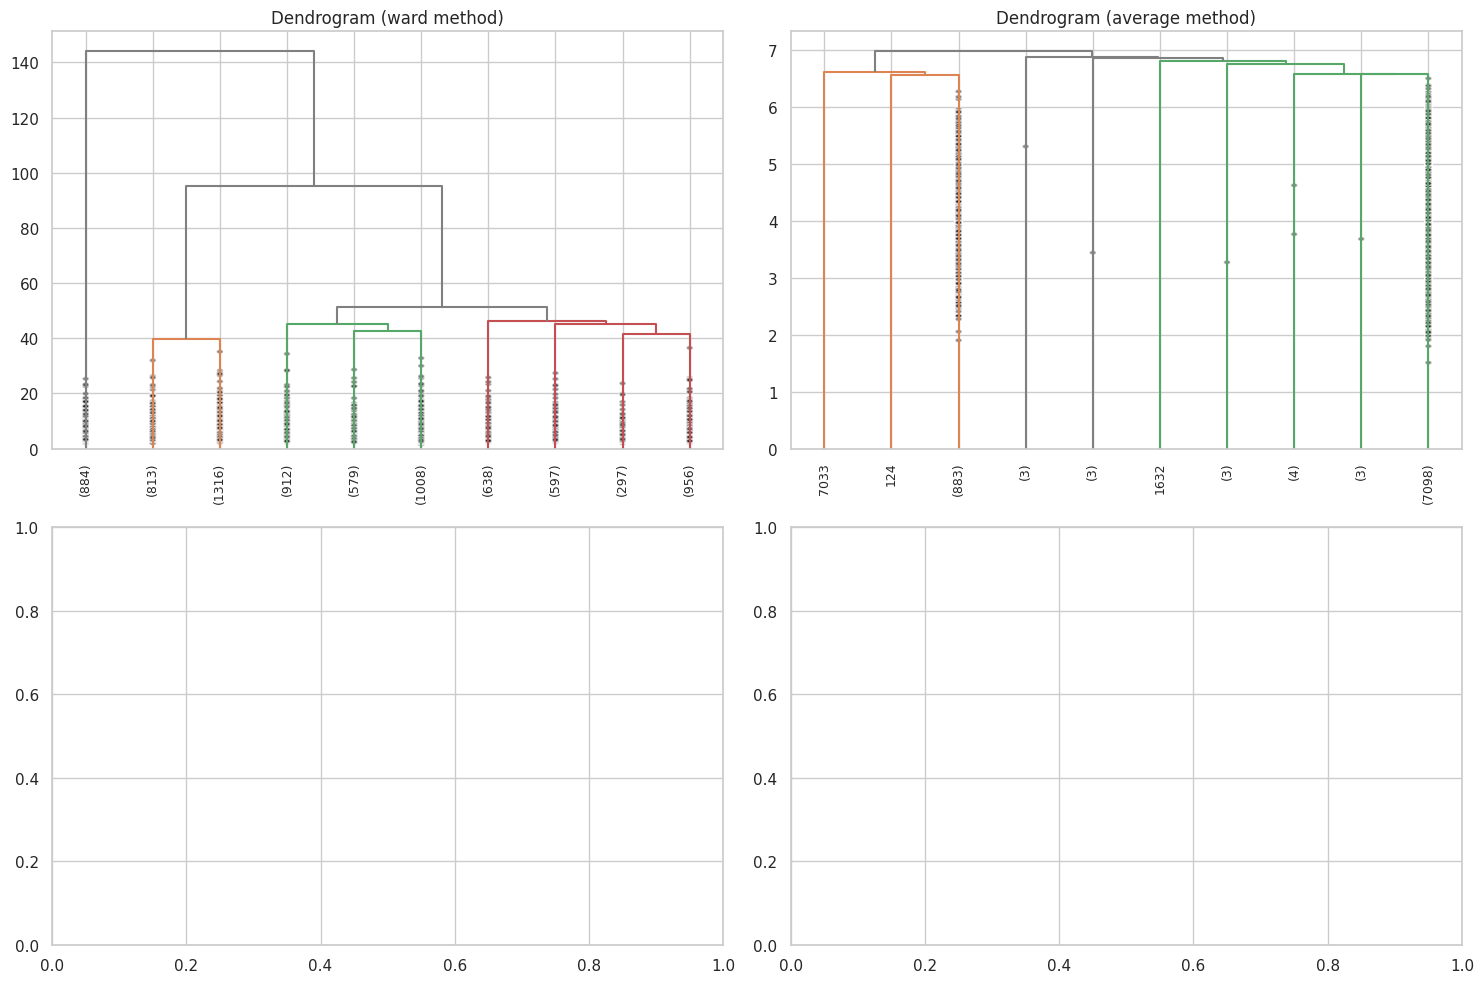

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# =========================================
# LOAD YOUR DATASET
# =========================================
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# =========================================
# SELECT NUMERICAL FEATURES
# =========================================
num_cols = df.select_dtypes(include=np.number).columns

# Remove target column if present
if 'final_score' in num_cols:
    num_cols = num_cols.drop('final_score')

X = df[num_cols].values

# =========================================
# FEATURE SCALING
# =========================================
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# =========================================
# DENDROGRAM PLOTS
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

methods = ['ward', 'average']
subplot_axes = [axes[0,0], axes[0,1]]

for i, method in enumerate(methods):
    Z = linkage(X_scaled, method=method)

    dendrogram(
        Z,
        ax=subplot_axes[i],
        p=10,
        truncate_mode='lastp',
        show_contracted=True,
        leaf_font_size=9,
        leaf_rotation=90,
        color_threshold=Z[-3, 2],
        above_threshold_color='gray'
    )

    subplot_axes[i].set_title(f'Dendrogram ({method} method)')

plt.tight_layout()
plt.show()

DBSCAN Results:
Clusters found: 0
Noise points: 8000 (labelled -1)
Cluster sizes: {np.int64(-1): np.int64(8000)}


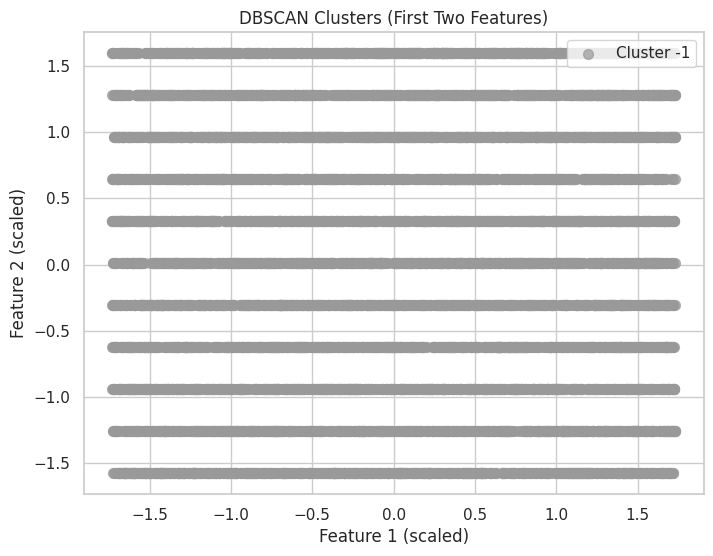

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# =========================================
# LOAD YOUR DATASET
# =========================================
df = pd.read_csv("ai_impact_student_performance_dataset.csv")

# =========================================
# SELECT NUMERICAL FEATURES
# =========================================
num_cols = df.select_dtypes(include=np.number).columns

# Remove target column if present
if 'final_score' in num_cols:
    num_cols = num_cols.drop('final_score')

X = df[num_cols].values

# =========================================
# FEATURE SCALING
# =========================================
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# =========================================
# DBSCAN PARAMETERS
# =========================================
eps = 0.5
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

# =========================================
# RESULTS
# =========================================
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print("DBSCAN Results:")
print("Clusters found:", n_clusters_db)
print("Noise points:", n_noise, "(labelled -1)")
print("Cluster sizes:", dict(zip(*np.unique(db_labels, return_counts=True))))

# =========================================
# SILHOUETTE SCORE
# =========================================
if n_clusters_db > 1:
    non_noise = db_labels != -1
    print("Silhouette (excluding noise):",
          silhouette_score(X_scaled[non_noise], db_labels[non_noise]))

# =========================================
# VISUALIZATION (FIRST TWO FEATURES)
# =========================================
unique_labels = set(db_labels)

colors = {-1: '#999999', 0: '#4C72B0', 1: '#55A868', 2: '#C44E52', 3: '#8172B2'}

plt.figure(figsize=(8, 6))

for lbl in unique_labels:
    mask = db_labels == lbl
    color = colors.get(lbl, '#000000')

    plt.scatter(
        X_scaled[mask, 0],
        X_scaled[mask, 1],
        c=color,
        label=f'Cluster {lbl}',
        s=50,
        alpha=0.7
    )

plt.title("DBSCAN Clusters (First Two Features)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.show()

In [ ]:
df = pd.read_csv('ai_impact_student_performance_dataset.csv')

# Assuming 'performance_category' is the target column for classification example
TARGET = 'performance_category'

# Features would be all columns except 'student_id' and the TARGET
ORIGINAL_FEATURES = [col for col in df.columns if col not in ['student_id', TARGET]]

# Label encode the target if it's categorical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df[TARGET])

print('Shape:', df.shape)
print('Class distribution:\n', df[TARGET].value_counts())
df.head(6)

Shape: (8000, 27)
Class distribution:
 performance_category
Medium    4705
Low       2542
High       753
Name: count, dtype: int64


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category,label
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low,1
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium,2
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium,2
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium,2
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low,1
5,6,20,Male,1st Year,5.1,1,34,Copilot,Coding,10,...,8.0,13.4,5.5,3.7,2.1,4,77.9,1,High,0


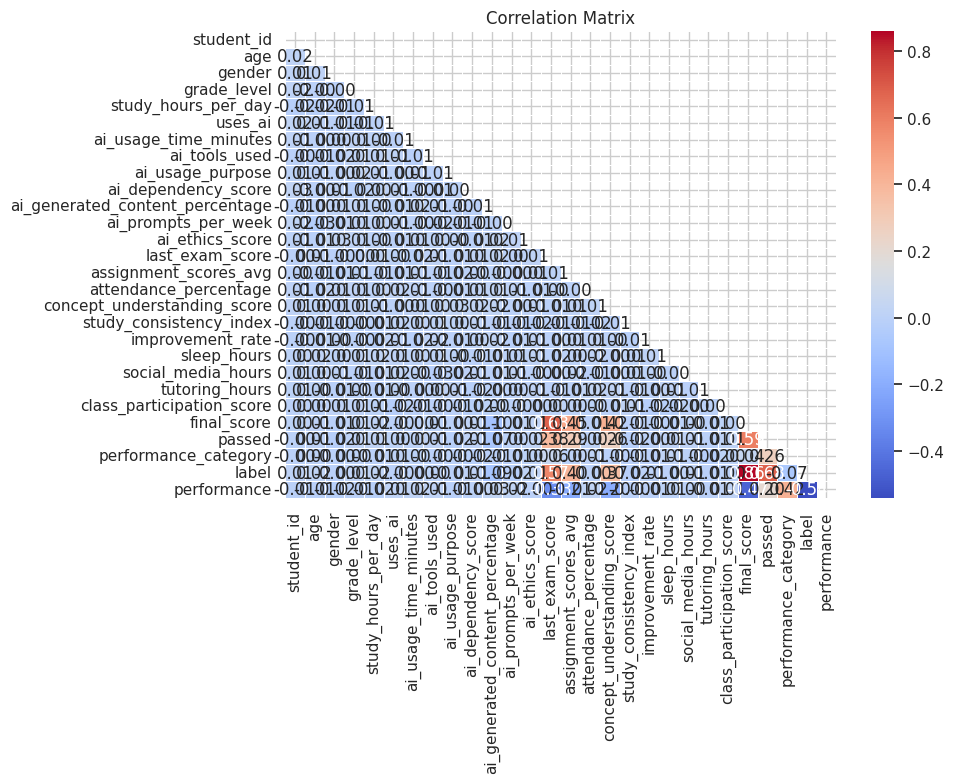

In [ ]:
df = df.drop(columns=['sum', 'id'], errors='ignore')

# =========================================
# ENCODE CATEGORICAL DATA
# =========================================
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# =========================================
# CORRELATION MATRIX
# =========================================
corr = df.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# =========================================
# HEATMAP
# =========================================
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    mask=mask,
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ── 2A: Domain-inspired feature creation ──────────────────────────────────────
df_feat = df.copy()

# --- Ratio features ---
df_feat['Study_AI_Ratio'] = df_feat['study_hours_per_day'] / (df_feat['ai_usage_time_minutes'] + 1e-6)
df_feat['AI_Per_Prompt']  = df_feat['ai_usage_time_minutes'] / (df_feat['ai_prompts_per_week'] + 1e-6)

# --- Combined Scores ---
df_feat['Overall_Academic_Score'] = df_feat['last_exam_score'] + df_feat['assignment_scores_avg'] + df_feat['concept_understanding_score']
df_feat['Total_Engagement']     = df_feat['study_hours_per_day'] + df_feat['ai_usage_time_minutes'] / 60 # Convert minutes to hours

# --- Difference features ---
df_feat['Exam_Assignment_Diff'] = df_feat['last_exam_score'] - df_feat['assignment_scores_avg']

# --- Log transforms (reduce skewness) ---
df_feat['Log_Study_Hours']  = np.log1p(df_feat['study_hours_per_day'])
df_feat['Log_AIAccess_Time'] = np.log1p(df_feat['ai_usage_time_minutes'])

# --- Interaction feature ---
df_feat['Study_Attendance_Interaction'] = df_feat['study_hours_per_day'] * df_feat['attendance_percentage']

NEW_FEATURES = [
    'Study_AI_Ratio',
    'AI_Per_Prompt',
    'Overall_Academic_Score',
    'Total_Engagement',
    'Exam_Assignment_Diff',
    'Log_Study_Hours',
    'Log_AIAccess_Time',
    'Study_Attendance_Interaction'
]

print(f'Original features : {len(ORIGINAL_FEATURES)}')
print(f'Engineered features: {len(NEW_FEATURES)}')
print(f'Total features     : {len(ORIGINAL_FEATURES) + len(NEW_FEATURES)}')
df_feat[ORIGINAL_FEATURES + NEW_FEATURES].head(5).round(3)

Original features : 24
Engineered features: 8
Total features     : 32


,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,...,final_score,passed,Study_AI_Ratio,AI_Per_Prompt,Overall_Academic_Score,Total_Engagement,Exam_Assignment_Diff,Log_Study_Hours,Log_AIAccess_Time,Study_Attendance_Interaction
0,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,29,...,36.8,0,0.015,3.036,73.9,5.333,-11.9,1.253,5.142,247.00
1,17,Male,12th,3.4,1,123,NaN,Notes,4,14,...,65.5,1,0.028,1.892,155.2,5.450,-27.2,1.482,4.820,303.62
2,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,82,...,66.3,1,0.023,4.375,182.1,1.383,20.9,0.588,3.584,40.64
3,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,74,...,69.5,1,0.098,0.425,158.4,5.150,-19.4,1.686,3.829,229.24
4,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,83,...,49.7,1,0.167,3.000,114.4,3.850,-29.4,1.504,3.091,142.45


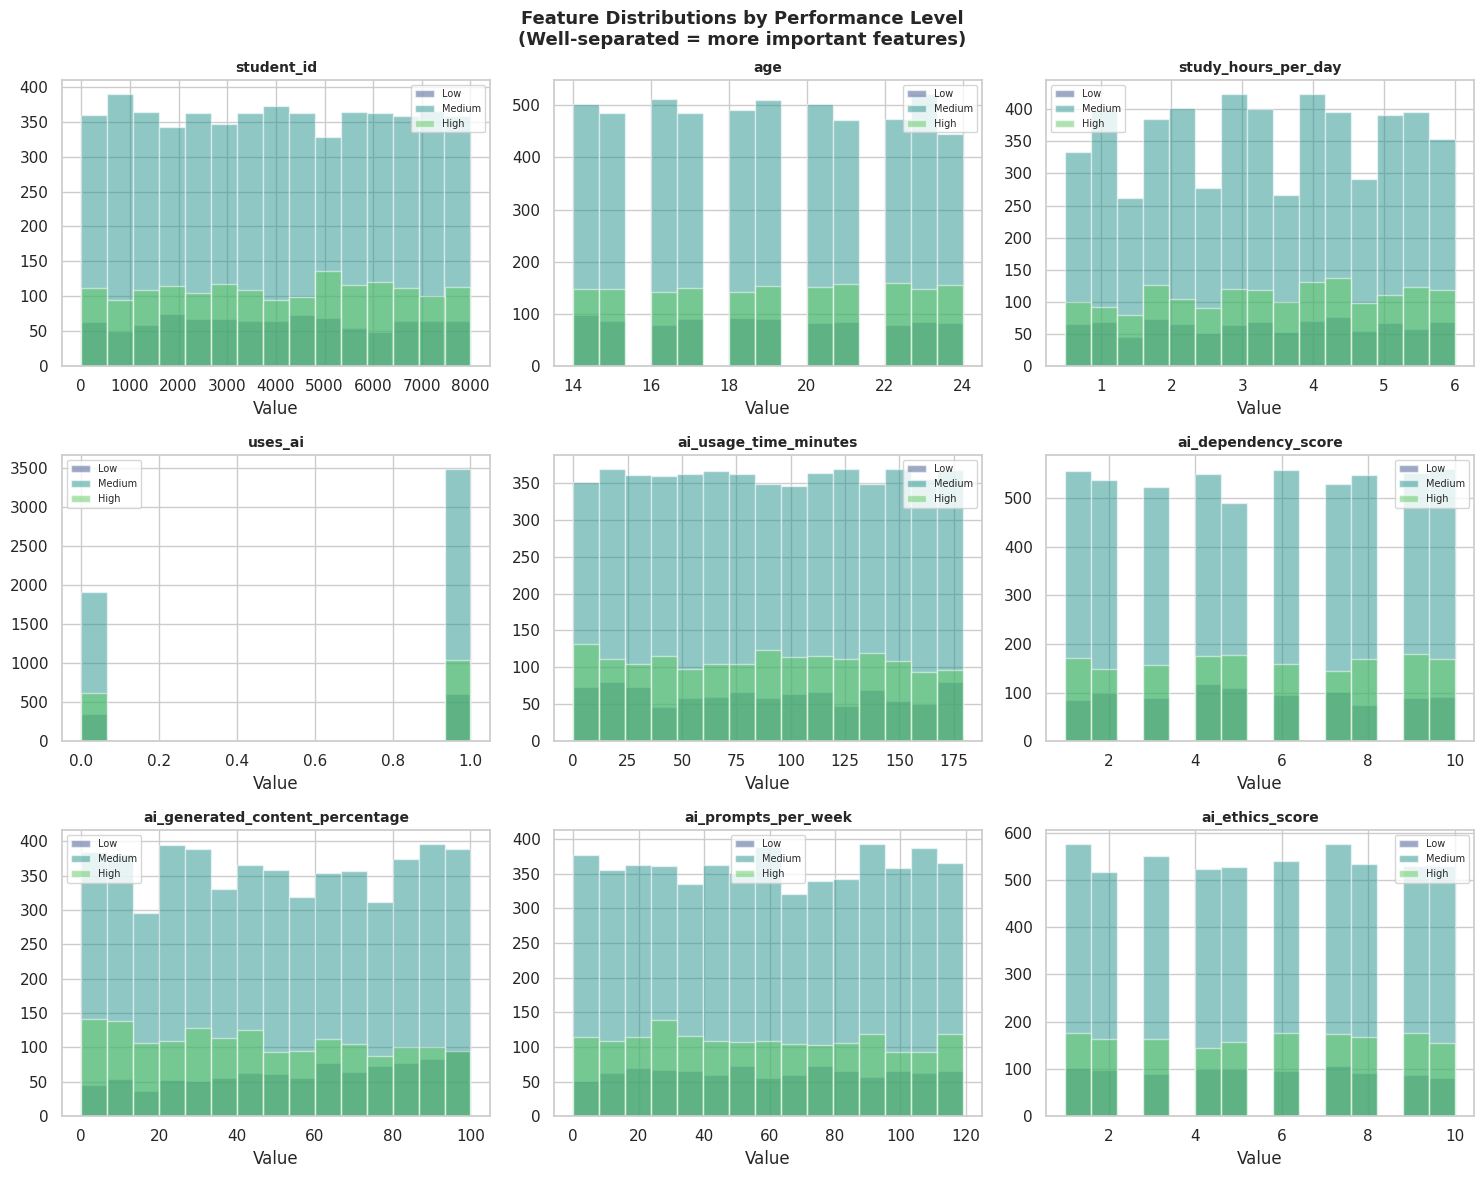

In [ ]:
df['performance'] = pd.cut(
    df['final_score'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

TARGET = 'performance'

# =========================================
# SELECT FEATURES
# =========================================
# Use numeric features
FEATURES = df.select_dtypes(include='number').columns.tolist()

# Remove target if present
if 'final_score' in FEATURES:
    FEATURES.remove('final_score')

# =========================================
# PLOTTING
# =========================================
palette = sns.color_palette('viridis', n_colors=len(df[TARGET].unique()))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, feat in zip(axes, FEATURES):
    for category, color in zip(df[TARGET].unique(), palette):
        subset = df[df[TARGET] == category][feat]

        ax.hist(subset, bins=15, alpha=0.5,
                color=color, label=category)

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(fontsize=7)

plt.suptitle(
    'Feature Distributions by Performance Level\n'
    '(Well-separated = more important features)',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
print("Columns:\n", df.columns)

# =========================================
# SELECT FEATURES
# =========================================
# Select all features except target
TARGET = 'final_score'

features = df.drop(columns=[TARGET], errors='ignore')

# =========================================
# HANDLE CATEGORICAL DATA (Label Encoding)
# =========================================
le_dict = {}

# Include both 'object' and 'category' dtypes for label encoding
for col in features.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    features[col] = le.fit_transform(features[col].astype(str))
    le_dict[col] = le

# =========================================
# APPLY POLYNOMIAL FEATURES
# =========================================
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(features)

# Get feature names
poly_names = poly.get_feature_names_out(features.columns)

# =========================================
# OUTPUT
# =========================================
print(f"\nOriginal features  : {features.shape[1]}")
print(f"Polynomial features: {len(poly_names)}")

print("\nFirst 20 Polynomial Feature Names:")
for i, name in enumerate(poly_names[:20]):
    print(f"{i+1:2d}. {name}")

Columns:
 Index(['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day',
       'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose',
       'ai_dependency_score', 'ai_generated_content_percentage',
       'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
       'assignment_scores_avg', 'attendance_percentage',
       'concept_understanding_score', 'study_consistency_index',
       'improvement_rate', 'sleep_hours', 'social_media_hours',
       'tutoring_hours', 'class_participation_score', 'final_score', 'passed',
       'performance_category', 'label', 'performance'],
      dtype='object')

Original features  : 27
Polynomial features: 405

First 20 Polynomial Feature Names:
 1. student_id
 2. age
 3. gender
 4. grade_level
 5. study_hours_per_day
 6. uses_ai
 7. ai_usage_time_minutes
 8. ai_tools_used
 9. ai_usage_purpose
10. ai_dependency_score
11. ai_generated_content_percentage
12. ai_prompts_per_week
13. ai_ethics_score
14. last_exam_sco

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


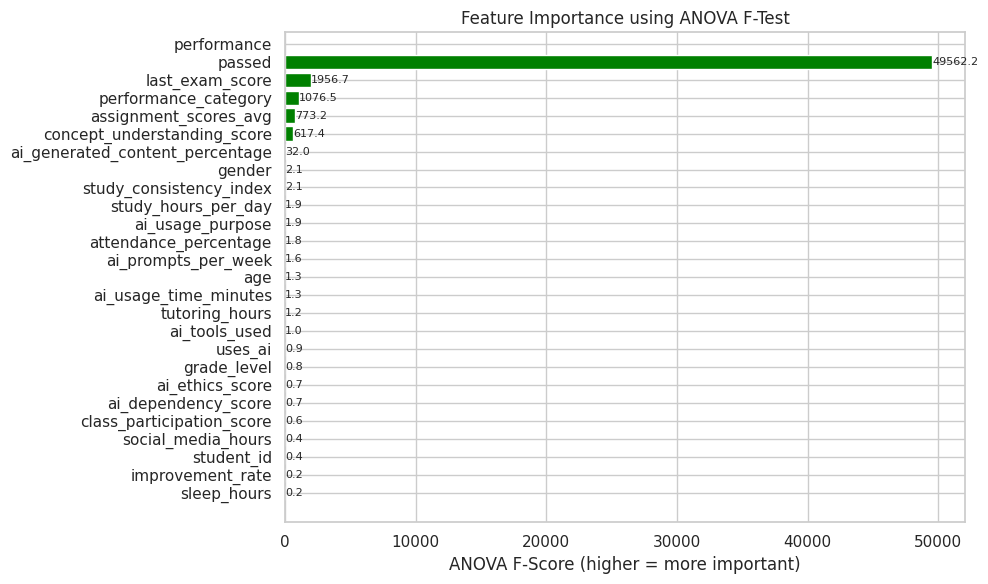


Top 5 most important features:
                  Feature       F-Score        p-value
25            performance           inf   0.000000e+00
23                 passed  4.956225e+04   0.000000e+00
13        last_exam_score  1.956676e+03   0.000000e+00
24   performance_category  1.076522e+03   0.000000e+00
14  assignment_scores_avg  7.732436e+02  9.889202e-308


In [ ]:
df['label'] = pd.cut(
    df['final_score'],
    bins=3,
    labels=[0, 1, 2]   # Low, Medium, High
)

# =========================================
# PREPARE FEATURES
# =========================================
X = df.drop(columns=['final_score', 'label'], errors='ignore').copy()
y = df['label']

# =========================================
# ENCODE CATEGORICAL DATA
# =========================================
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# =========================================
# APPLY ANOVA F-TEST
# =========================================
f_scores, p_values = f_classif(X, y)

fi_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values('F-Score', ascending=False)

# =========================================
# VISUALIZATION
# =========================================
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if p < 0.05 else 'red' for p in fi_df['p-value']]

bars = ax.barh(fi_df['Feature'][::-1],
               fi_df['F-Score'][::-1],
               color=colors[::-1])

ax.set_xlabel('ANOVA F-Score (higher = more important)')
ax.set_title('Feature Importance using ANOVA F-Test')

# Add values on bars
for bar, val in zip(bars, fi_df['F-Score'][::-1]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# =========================================
# TOP FEATURES
# =========================================
print("\nTop 5 most important features:")
print(fi_df.head(5))

In [ ]:
df_feat['FinalScore_Bin'] = pd.cut(
    df_feat['final_score'],
    bins=[0, 40, 70, 100], # Example bins for final scores
    labels=['Low (<40)', 'Medium (40-70)', 'High (>70)']
)

print('FinalScore binning distribution:')
print(pd.crosstab(df_feat['FinalScore_Bin'], df_feat['performance_category']))

FinalScore binning distribution:
performance_category    0     1     2
FinalScore_Bin                       
Low (<40)               0   899     0
Medium (40-70)          0  1643  4091
High (>70)            753     0   614


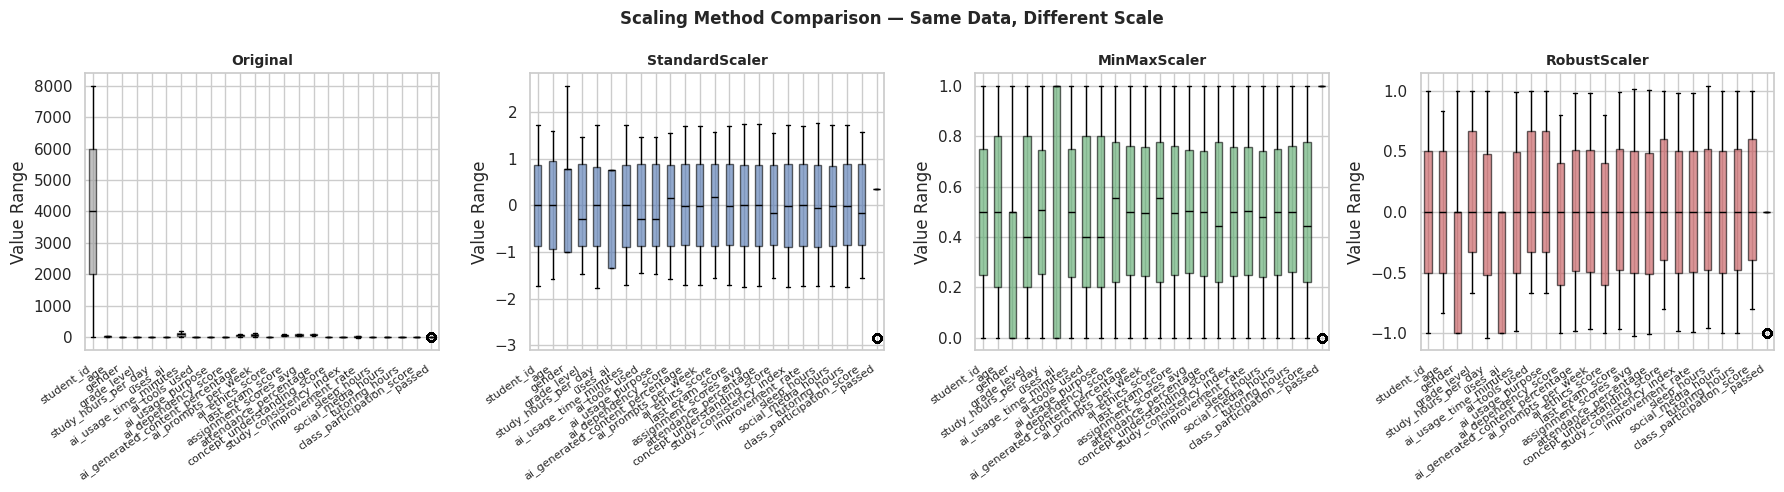

In [ ]:
TARGET = 'final_score'
df_scaled = df.drop(columns=[TARGET, 'performance', 'performance_category', 'label'], errors='ignore').copy()

# =========================================
# ENCODE CATEGORICAL FEATURES
# =========================================
for col in df_scaled.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_scaled[col] = le.fit_transform(df_scaled[col].astype(str))

# =========================================
# NUMERICAL DATA FOR SCALING
# =========================================
X_raw = df_scaled.values
feature_names = df_scaled.columns

# =========================================
# APPLY SCALERS
# =========================================
scalers = {
    'Original': X_raw,
    'StandardScaler': StandardScaler().fit_transform(X_raw),
    'MinMaxScaler': MinMaxScaler().fit_transform(X_raw),
    'RobustScaler': RobustScaler().fit_transform(X_raw),
}

# =========================================
# VISUALIZATION (BOXPLOTS)
# =========================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colors = ['#999999', '#4C72B0', '#55A868', '#C44E52']

for ax, (name, Xs), color in zip(axes, scalers.items(), colors):
    ax.boxplot(
        Xs,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black')
    )

    ax.set_xticklabels(feature_names, rotation=35, ha='right', fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Value Range')

plt.suptitle(
    'Scaling Method Comparison — Same Data, Different Scale',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
SEED = 42

# =========================================
# CREATE TARGET (CLASSIFICATION)
# =========================================
# Convert final_score → classes
df['label'] = pd.cut(
    df['final_score'],
    bins=3,
    labels=[0, 1, 2]   # Low, Medium, High
)

# =========================================
# SELECT FEATURES
# =========================================
X = df.drop(columns=['final_score', 'label', 'performance_category', 'performance'], errors='ignore').copy()
y = df['label']

# =========================================
# ENCODE CATEGORICAL DATA
# =========================================
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

# =========================================
# SCALING + SVM COMPARISON
# =========================================
scale_results = {}

for name, scaler in [
    ('No Scaling', None),
    ('StandardScaler', StandardScaler()),
    ('MinMaxScaler', MinMaxScaler()),
    ('RobustScaler', RobustScaler())
]:

    if scaler:
        Xtr_s = scaler.fit_transform(X_tr)
        Xte_s = scaler.transform(X_te)
    else:
        Xtr_s, Xte_s = X_tr.values, X_te.values

    svm = SVC(kernel='rbf', random_state=SEED)
    svm.fit(Xtr_s, y_tr)

    acc = accuracy_score(y_te, svm.predict(Xte_s))
    scale_results[name] = acc

# =========================================
# RESULTS
# =========================================
print("SVM Accuracy by Scaling Method:\n")

for name, acc in scale_results.items():
    bar = '█' * int(acc * 40)
    print(f"{name:18s}: {acc:.4f}  {bar}")

SVM Accuracy by Scaling Method:

No Scaling        : 0.6750  ███████████████████████████
StandardScaler    : 0.8975  ███████████████████████████████████
MinMaxScaler      : 0.8990  ███████████████████████████████████
RobustScaler      : 0.8990  ███████████████████████████████████


IQR bounds: [18.95, 94.55]
Outliers — IQR: 11 | Z-score: 7 | IsoForest: 400


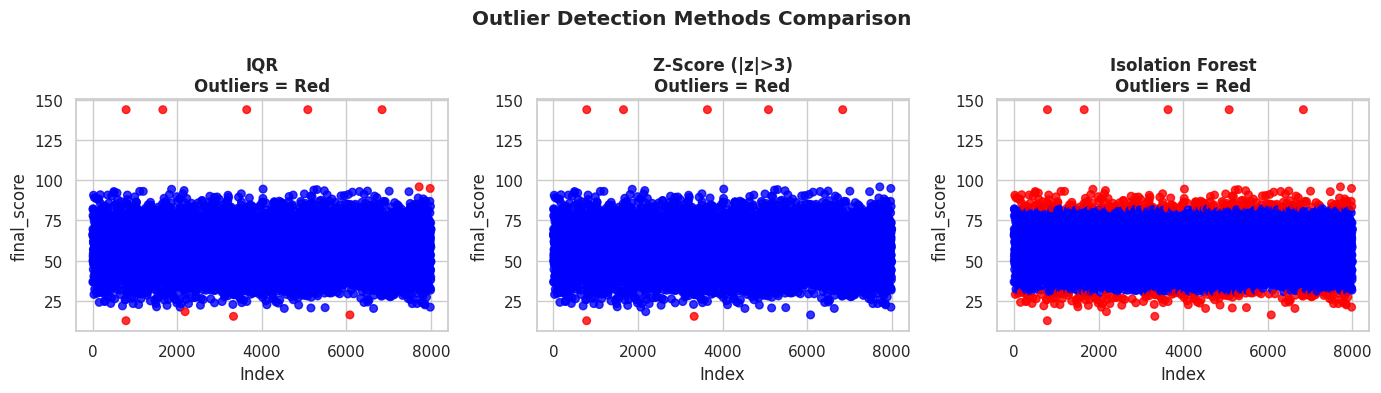

In [ ]:
SEED = 42

# =========================================
# SELECT NUMERIC COLUMN
# =========================================
col = 'final_score'   # 🔁 change if needed

df_outlier = df[[col]].copy()

# =========================================
# (OPTIONAL) INJECT OUTLIERS FOR DEMO
# =========================================
np.random.seed(7)
out_idx = np.random.choice(df_outlier.index, size=5, replace=False)
df_outlier.loc[out_idx, col] = df_outlier[col].max() * 1.5

# =========================================
# IQR METHOD
# =========================================
Q1 = df_outlier[col].quantile(0.25)
Q3 = df_outlier[col].quantile(0.75)
IQR = Q3 - Q1

lo = Q1 - 1.5 * IQR
hi = Q3 + 1.5 * IQR

iqr_mask = (df_outlier[col] < lo) | (df_outlier[col] > hi)

# =========================================
# Z-SCORE METHOD
# =========================================
z = np.abs(stats.zscore(df_outlier[col]))
z_mask = z > 3

# =========================================
# ISOLATION FOREST
# =========================================
iso = IsolationForest(contamination=0.05, random_state=SEED)
iso_pred = iso.fit_predict(df_outlier[[col]])
iso_mask = iso_pred == -1

# =========================================
# RESULTS
# =========================================
print(f"IQR bounds: [{lo:.2f}, {hi:.2f}]")
print(f"Outliers — IQR: {iqr_mask.sum()} | Z-score: {z_mask.sum()} | IsoForest: {iso_mask.sum()}")

# =========================================
# VISUALIZATION
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

methods = [
    ('IQR', iqr_mask),
    ('Z-Score (|z|>3)', z_mask),
    ('Isolation Forest', iso_mask)
]

for ax, (title, mask) in zip(axes, methods):
    ax.scatter(
        range(len(df_outlier)),
        df_outlier[col],
        c=['red' if m else 'blue' for m in mask],
        s=30,
        alpha=0.8
    )

    ax.set_title(f"{title}\nOutliers = Red", fontweight='bold')
    ax.set_xlabel("Index")
    ax.set_ylabel(col)

plt.suptitle("Outlier Detection Methods Comparison", fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


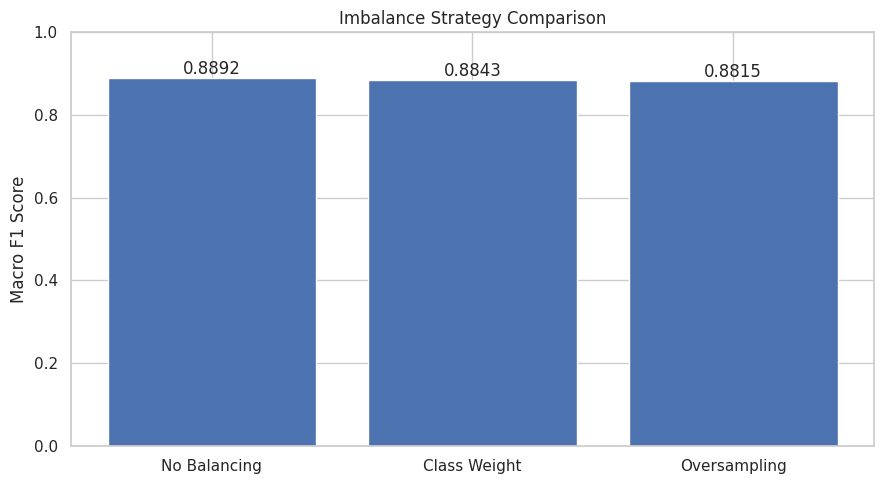

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler # Import StandardScaler
from sklearn.metrics import f1_score
from sklearn.utils import resample # Import resample

df['label'] = pd.cut(df['final_score'], bins=3, labels=[0, 1, 2])

# =========================================
# PREPARE FEATURES
# =========================================
X = df.drop(columns=['final_score', 'label', 'performance', 'performance_category'], errors='ignore').copy()
y = df['label']

# Encode categorical features
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# =========================================
# FEATURE SCALING
# =========================================
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

# =========================================
# STRATEGIES
# =========================================

# 1. No balancing
# Note: While 'no balancing', scaling is applied to all models for convergence
model1 = LogisticRegression(max_iter=2000) # Increased max_iter
model1.fit(X_tr_scaled, y_tr) # Use scaled data
pred1 = model1.predict(X_te_scaled) # Use scaled data

# 2. Class weight
model2 = LogisticRegression(class_weight='balanced', max_iter=2000) # Increased max_iter
model2.fit(X_tr_scaled, y_tr) # Use scaled data
pred2 = model2.predict(X_te_scaled) # Use scaled data

# 3. Oversampling (simple)
df_train = pd.concat([pd.DataFrame(X_tr_scaled, columns=X_tr.columns), y_tr.reset_index(drop=True)], axis=1)
max_class = df_train['label'].value_counts().max()

# Collect resampled groups
resampled_groups = []
for name, group in df_train.groupby('label', observed=False):
    resampled_group = resample(
        group,
        replace=True,
        n_samples=max_class,
        random_state=42
    )
    resampled_groups.append(resampled_group)

df_balanced = pd.concat(resampled_groups).reset_index(drop=True)

X_os = df_balanced.drop(columns='label')
y_os = df_balanced['label']

model3 = LogisticRegression(max_iter=2000) # Increased max_iter
model3.fit(X_os, y_os)
pred3 = model3.predict(X_te_scaled) # Use scaled test data

# Store predictions
strategies = {
    'No Balancing': pred1,
    'Class Weight': pred2,
    'Oversampling': pred3
}

# =========================================
# F1 SCORE CALCULATION
# =========================================
strategy_names = list(strategies.keys())
f1_scores = [f1_score(y_te, preds, average='macro')
             for preds in strategies.values()]

# =========================================
# VISUALIZATION
# =========================================
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(strategy_names, f1_scores)

ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1 Score')
ax.set_title('Imbalance Strategy Comparison')

# Show values
for bar, v in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df['label'] = pd.cut(
    df['final_score'],
    bins=3,
    labels=[0, 1, 2]   # Low, Medium, High
)

# =========================================
# FEATURES & TARGET
# =========================================
X = df.drop(columns=['final_score', 'label'], errors='ignore').copy()
y = df['label']

# =========================================
# ENCODE CATEGORICAL DATA
# =========================================
for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# DECISION TREE MODEL
# =========================================
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# =========================================
# PREDICTION
# =========================================
y_pred = model.predict(X_test)

# =========================================
# ACCURACY
# =========================================
acc = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", acc)

# =========================================
# EXTRA (OPTIONAL BUT IMPORTANT)
# =========================================
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00      1080
           2       1.00      1.00      1.00       330

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600


Confusion Matrix:
 [[ 190    0    0]
 [   0 1080    0]
 [   0    0  330]]


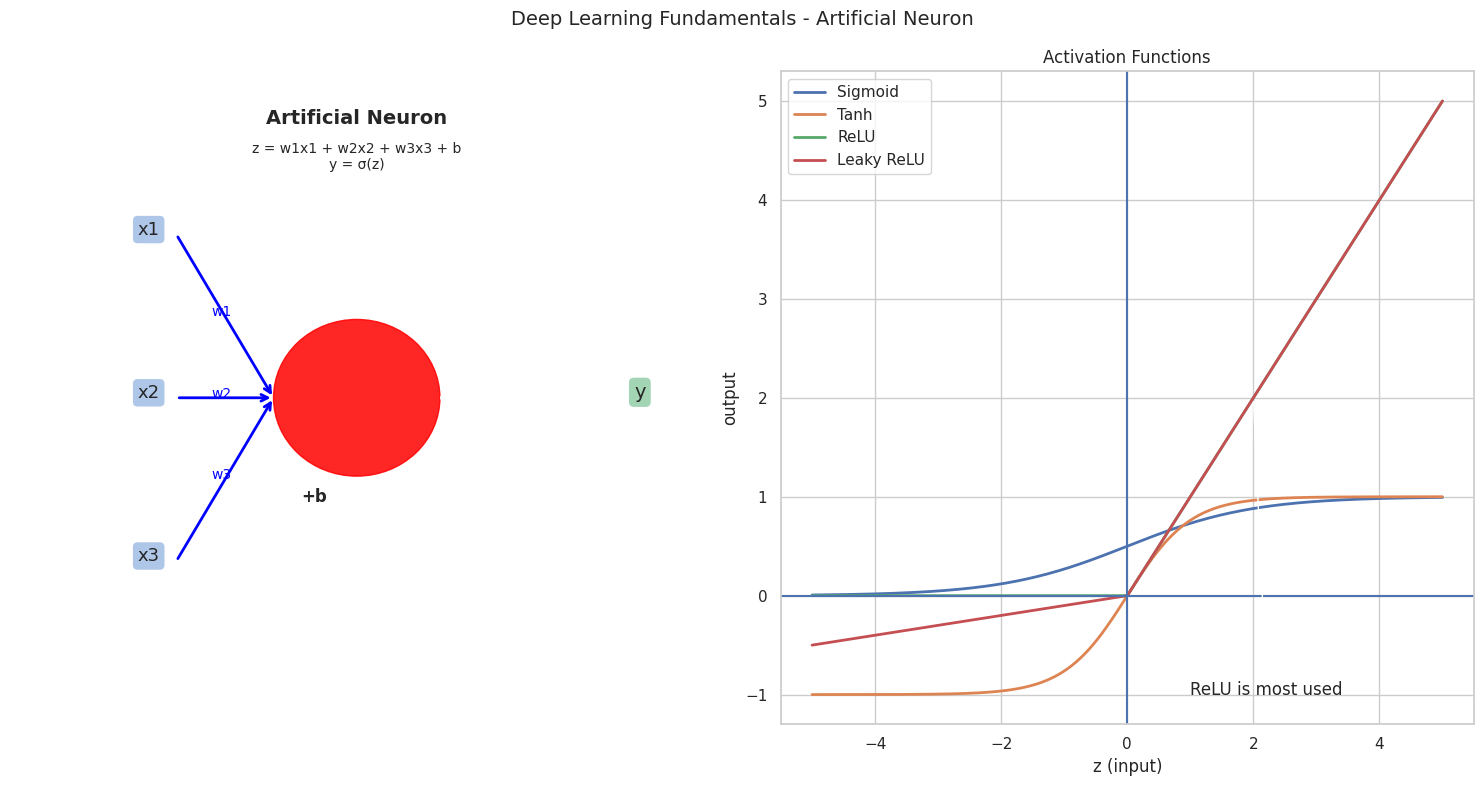

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# =========================================
# 1. ARTIFICIAL NEURON DIAGRAM
# =========================================
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Neuron (circle)
circle = plt.Circle((5, 5), 1.2, color='red', alpha=0.85)
ax.add_patch(circle)

# Inputs
inputs = [('x1', 2.0, 7.5, 'w1'),
          ('x2', 2.0, 5.0, 'w2'),
          ('x3', 2.0, 2.5, 'w3')]

for name, x, y, w in inputs:
    ax.annotate('', xy=(3.8, 5), xytext=(x + 0.4, y),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

    ax.text(x, y, name, ha='center', fontsize=13,
            bbox=dict(boxstyle='round', facecolor='#AEC6E8'))

    ax.text((x + 3.8) / 2, (y + 5) / 2, w,
            fontsize=10, color='blue')

# Bias
ax.text(4.2, 3.4, '+b', fontsize=12, fontweight='bold')

# Output arrow
ax.annotate('', xy=(8.5, 5), xytext=(6.2, 5),
            arrowprops=dict(arrowstyle='->', lw=4))

ax.text(9, 5, 'y', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='#A3D5B5'))

# Title + formula
ax.text(5, 9.2, 'Artificial Neuron', ha='center',
        fontsize=14, fontweight='bold')

ax.text(5, 8.5, 'z = w1x1 + w2x2 + w3x3 + b\ny = σ(z)',
        ha='center', fontsize=10)

# =========================================
# 2. ACTIVATION FUNCTIONS
# =========================================
ax2 = axes[1]

z = np.linspace(-5, 5, 300)

# Plot functions
ax2.plot(z, 1/(1+np.exp(-z)), label='Sigmoid', lw=2)
ax2.plot(z, np.tanh(z), label='Tanh', lw=2)
ax2.plot(z, np.maximum(0, z), label='ReLU', lw=2)
ax2.plot(z, np.where(z > 0, z, 0.1*z), label='Leaky ReLU', lw=2)

# Axis lines
ax2.axhline(0)
ax2.axvline(0)

ax2.set_title("Activation Functions")
ax2.set_xlabel("z (input)")
ax2.set_ylabel("output")

ax2.legend()

# Annotation
ax2.annotate('ReLU is most used',
             xy=(2, 2), xytext=(1, -1),
             arrowprops=dict(arrowstyle='->'))

# =========================================
# FINAL DISPLAY
# =========================================
plt.suptitle("Deep Learning Fundamentals - Artificial Neuron", fontsize=14)
plt.tight_layout()
plt.show()